Welcome to your notebook！

In [1]:
print("Hello Notebook")

Hello Notebook


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, model_selection

In [7]:
X, y = datasets.load_diabetes(return_X_y=True)
print(X.shape)
print(X[0])

(442, 10)
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [8]:
X = X[:, 2]
X = X.reshape((-1,1))

In [9]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33)

In [10]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [12]:
y_pred = model.predict(X_test)

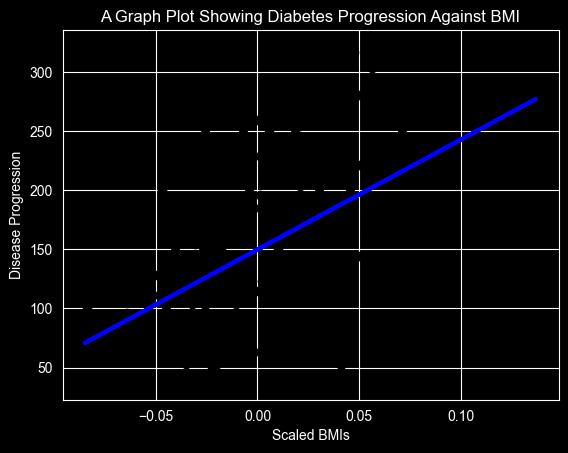

In [13]:
plt.scatter(X_test, y_test,  color='black')
plt.plot(X_test, y_pred, color='blue', linewidth=3)
plt.xlabel('Scaled BMIs')
plt.ylabel('Disease Progression')
plt.title('A Graph Plot Showing Diabetes Progression Against BMI')
plt.show()

In [14]:
model.coef_

array([928.34076496])

In [15]:
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [17]:
# 显示模型系数的具体值
print('\n=== 线性回归模型系数详细信息 ===')
print(f'系数向量维度: {model.coef_.shape}')
print(f'系数值: {model.coef_[0]:.6f}')
print(f'系数数据类型: {model.coef_.dtype}')
print(f'系数绝对值: {abs(model.coef_[0]):.6f}')
print(f'模型截距: {model.intercept_:.6f}')

# 完整的回归方程
print(f'\n回归方程: y = {model.coef_[0]:.6f} * x + {model.intercept_:.6f}')

# 计算R²分数
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f'模型R²分数: {r2:.4f}')

# 计算系数对预测的影响
print(f'\n=== 系数解释 ===')
print(f'当BMI标准化值增加1个单位时，糖尿病进展预计增加 {model.coef_[0]:.6f} 个单位')
print(f'当BMI标准化值为0时，基准糖尿病进展为 {model.intercept_:.6f}')


=== 线性回归模型系数详细信息 ===
系数向量维度: (1,)
系数值: 928.340765
系数数据类型: float64
系数绝对值: 928.340765
模型截距: 149.659412

回归方程: y = 928.340765 * x + 149.659412
模型R²分数: 0.3566

=== 系数解释 ===
当BMI标准化值增加1个单位时，糖尿病进展预计增加 928.340765 个单位
当BMI标准化值为0时，基准糖尿病进展为 149.659412



=== 系数统计推断 ===
系数标准误差（近似）: 68.013680
系数95%置信区间: [795.610702, 1058.054612]
系数t统计量（近似）: 13.6493
系数p-value（近似）: 0.000000

=== 系数重要性评估 ===
✅ 系数在统计上显著（p < 0.05）


/Users/duobinji/Documents/GitHub/ML-For-Beginners/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/duobinji/Documents/GitHub/ML-For-Beginners/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/duobinji/Documents/GitHub/ML-For-Beginners/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/duobinji/Documents/GitHub/ML-For-Beginners/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/duobinji/Docu

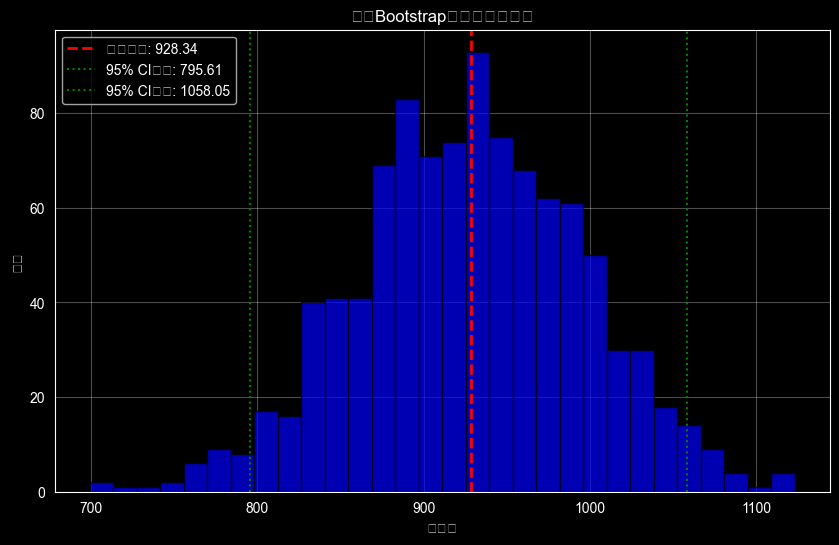

In [19]:
# 系数的统计检验和置信区间
import scipy.stats as stats

# 计算标准误差和t统计量
# 注：scikit-learn的LinearRegression不直接提供标准误差，但我们可以计算
# 使用bootstrap方法近似计算置信区间
n_bootstraps = 1000
bootstrap_coefs = []

# 使用bootstrap采样
for i in range(n_bootstraps):
    # 有放回地采样
    indices = np.random.choice(len(X_train), len(X_train), replace=True)
    X_boot = X_train[indices]
    y_boot = y_train[indices]
    
    # 训练新模型
    model_boot = linear_model.LinearRegression()
    model_boot.fit(X_boot, y_boot)
    bootstrap_coefs.append(model_boot.coef_[0])

bootstrap_coefs = np.array(bootstrap_coefs)

# 计算置信区间
ci_lower = np.percentile(bootstrap_coefs, 2.5)
ci_upper = np.percentile(bootstrap_coefs, 97.5)
std_error = np.std(bootstrap_coefs)

print('\n=== 系数统计推断 ===')
print(f'系数标准误差（近似）: {std_error:.6f}')
print(f'系数95%置信区间: [{ci_lower:.6f}, {ci_upper:.6f}]')
print(f'系数t统计量（近似）: {model.coef_[0]/std_error:.4f}')

# 计算p-value（近似）
z_score = model.coef_[0]/std_error
p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'系数p-value（近似）: {p_value:.6f}')

# 系数重要性评估
print('\n=== 系数重要性评估 ===')
if abs(model.coef_[0]) > 2 * std_error:  # 约95%置信水平
    print('✅ 系数在统计上显著（p < 0.05）')
else:
    print('❌ 系数在统计上不显著')

# 可视化系数分布
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_coefs, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(model.coef_[0], color='red', linestyle='--', linewidth=2, label=f'原始系数: {model.coef_[0]:.2f}')
plt.axvline(ci_lower, color='green', linestyle=':', linewidth=1.5, label=f'95% CI下限: {ci_lower:.2f}')
plt.axvline(ci_upper, color='green', linestyle=':', linewidth=1.5, label=f'95% CI上限: {ci_upper:.2f}')
plt.xlabel('系数值')
plt.ylabel('频率')
plt.title('系数Bootstrap分布与置信区间')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()